# The nonlinear Ramsey problem

**Reader question.** What is the five-state nonlinear Ramsey object, and what must be
verified before a numerical solver can say anything about policy?

**Answer in brief.** The richer Brownian model is a stationary five-state HJB in
productivity, automation, log capital, public net worth, and the tax rate. Value
derivatives recover consumption, tax speed, and the risky position. Current code has
completed a primitive and sampled-domain screen, but it has not solved this HJB.

This is therefore a complete **formulation-and-diagnostic notebook**, not a nonlinear
policy result. Its numerical evidence is `exploratory_only` and the PDE itself remains
`diagnose_before_scaling`.

## Model, state, and controls

On the Brownian Version 5.1, $q_D=1$, smooth full-specialization interior branch,

$$
S=(z,x,k,n,\tau),\qquad
(\chi,\theta,\nu)=(c/K,\;s/K,\;\dot\tau).
$$

The two OU shocks enter through $z$ and $x$. Capital and public net worth are scaled by
capital; welfare is worker-only; the risky instrument is an external claim rather than
domestic public equity. The maintained numerical object is a smooth interior solution,
not a global constrained solution or transition path.

The state box, reference floor, and artificial numerical guardrails serve different
purposes. The reference floor is not asserted to be the true solvency frontier, and a
box face is not an economic boundary condition.

## HJB and recovered controls

For normalized value $v(S)$, the optimized smooth-interior equation is

$$
\begin{aligned}
\rho v={}&-\log v_n-1+\mathcal L^{z,x}v
+g\left(\frac1\rho+v_k\right)+[(r_I-g)n+f]v_n\\
&+\frac{\kappa_\tau}{2y}\frac{v_\tau^2}{v_n}
-\frac{(\beta_Iv_n+D_v)^2}{2\beta_Iv_{nn}},
\end{aligned}
$$

with

$$
\chi=\frac1{v_n},\qquad
\nu=\frac{\kappa_\tau}{y}\frac{v_\tau}{v_n},\qquad
\theta=-\frac{\beta_Iv_n+D_v}{\beta_Iv_{nn}}.
$$

These quotients explain why $v_n>0$, $v_{nn}<0$, and $\beta_I>0$ are structural
requirements. An implementation must evaluate optimized and unoptimized residuals by
independent algebraic paths; substituting recovered controls into the same routine
would not detect a shared transcription error.

## What the implemented pre-solve screen checks

The frozen CS004 Block 1 export records a deterministic factorial design, seeded
interior points, and dense one-dimensional automation scans. It checks primitive
finiteness, derivative signs, specialization margins, claim variance, and reference-
floor coverage. It contains no value function, HJB residual, recovered policy, or path
simulation.

In [1]:
import json
from pathlib import Path
from IPython.display import Markdown, display

data_path = next(
    path
    for path in (
        Path("notebooks/data/cs004_presolve_snapshot.json"),
        Path("data/cs004_presolve_snapshot.json"),
    )
    if path.exists()
)
snapshot = json.loads(data_path.read_text(encoding="utf-8"))
source = snapshot["source"]
design = snapshot["design_summary"]

lines = [
    f"**Status:** `{snapshot['result_use_status']}`; `{snapshot['disposition']}`  ",
    f"**Run:** `{source['run_id']}`  ",
    f"**Provenance warning:** {source['provenance_warning']}",
    "",
    "| Sample component | Points |",
    "|---|---:|",
]
for name, count in design.items():
    lines.append(f"| `{name}` | {count:,} |")
lines.extend(
    [
        "",
        f"Nonfinite sampled points: **{snapshot['nonfinite_point_count']}**",
        "",
        "These counts describe sampled points, not proof over the continuous domain.",
    ]
)
display(Markdown("\n".join(lines)))

**Status:** `exploratory_only`; `diagnose_before_scaling`  
**Run:** `RUN-20260901T204946Z-CS004-2713208-01`  
**Provenance warning:** The run record names an older commit than the final frozen screen implementation, so the run is not accepted evidence.

| Sample component | Points |
|---|---:|
| `buffer:factorial_grid` | 243 |
| `buffer:seeded_interior` | 1,500 |
| `central:factorial_grid` | 243 |
| `central:seeded_interior` | 1,000 |
| `total` | 2,986 |

Nonfinite sampled points: **0**

These counts describe sampled points, not proof over the continuous domain.

## Sampled branch margins and the reference floor

The left panel reports the smallest specialization margins seen in the central and
buffer samples. The right panel reports the fraction of central points with at least
$\eta_{sol}=0.01$ slack above the declared reference floor. Positive sampled margins
support continued implementation work; they do not make the entire box viable.

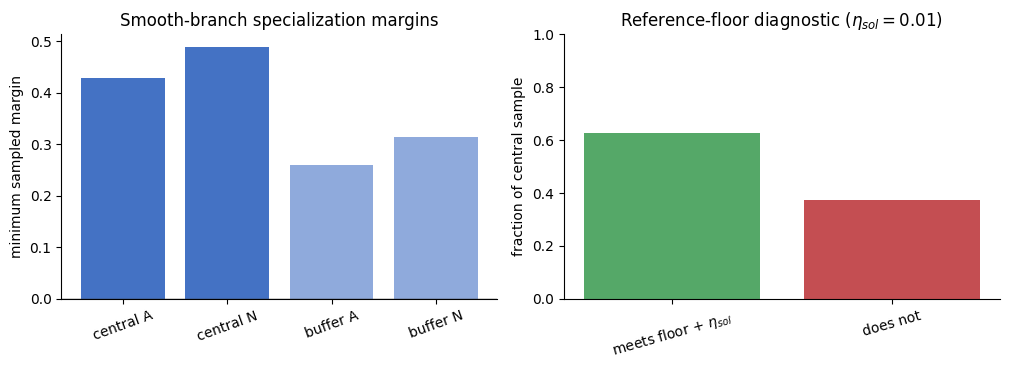

Dense buffer scan: $\beta_I\in[0.0013505, 0.0017008]$.  
Reference-floor formula: `n_ref(tau) = -0.12 * tau * (1 - tau)`.

In [2]:
import matplotlib.pyplot as plt

minima = snapshot["sampled_minima"]
reference = snapshot["reference_floor"]
labels = ["central A", "central N", "buffer A", "buffer N"]
values = [
    minima["central_specialisation_automation"],
    minima["central_specialisation_new_task"],
    minima["buffer_specialisation_automation"],
    minima["buffer_specialisation_new_task"],
]

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.8))
axes[0].bar(labels, values, color=["#4472C4", "#4472C4", "#8FAADC", "#8FAADC"])
axes[0].axhline(0, color="0.25", linewidth=1)
axes[0].set_ylabel("minimum sampled margin")
axes[0].set_title("Smooth-branch specialization margins")
axes[0].tick_params(axis="x", rotation=20)

fraction = reference["central_fraction_meeting"]
axes[1].bar(["meets floor + $\\eta_{sol}$", "does not"], [fraction, 1 - fraction],
            color=["#55A868", "#C44E52"])
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("fraction of central sample")
axes[1].set_title(f"Reference-floor diagnostic ($\\eta_{{sol}}={reference['eta_sol']}$)")
axes[1].tick_params(axis="x", rotation=16)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

display(
    Markdown(
        f"Dense buffer scan: $\\beta_I\\in[{minima['buffer_beta_I_dense_min']:.7f}, "
        f"{minima['buffer_beta_I_dense_max']:.7f}]$.  \n"
        f"Reference-floor formula: `{reference['formula']}`."
    )
)

## What is established—and what is not

| Established for the frozen sampled design | Still required before a PDE result |
|---|---|
| Primitive evaluations are finite on sampled points | A value candidate and value derivatives |
| Sampled automation/output/wage sign checks have no recorded violation | Independently coded optimized and unoptimized HJB residuals |
| Sampled specialization and $\beta_I$ margins are positive | FOC, curvature, and policy-recovery checks |
| 62.6% of the central sample clears the declared floor by 0.01 | Closed-loop ordinary and boundary-stress paths |
| Configuration and source hashes are recorded | Seed, capacity, box, and solver-method refinements |
| The screen runs cheaply in FP64 on CPU | Matched PDE–LQ bridge and claim-specific error budget |

The screen's upstream “pass with localized warnings” is a Block 1 diagnostic outcome.
It is not acceptance of the run as nonlinear model evidence, partly because the run
record names an older code commit and because later acceptance gates do not yet exist.

## Economic interpretation and limitation

The nonlinear formulation matters because public wealth, tax capacity, and portfolio
exposure interact away from the steady state; the LQ model can only approximate this
locally. The screen says the selected illustrative box is not immediately destroyed by
nonfinite primitives or negative sampled branch margins. It says nothing about the
shape of $v$, optimal controls, global feasibility, welfare, or the true solvency
frontier.

The safe wording ceiling is: **the frozen pre-solve screen finds finite primitives and
positive smooth-branch margins on sampled points of an illustrative five-state box.**

## Reproduce and trace

- Source: [`tai-public-finance-ramsey-pde` at `b287168`](https://github.com/Nathan-Barnard/tai-public-finance-ramsey-pde/tree/b287168c8593a5110ca52eb8bc19890f76fbb85b)
- Frozen screen implementation: `8815c82e980b87a892bbb30860e9bb83acdf87ed`
- Run: `RUN-20260901T204946Z-CS004-2713208-01` (commit mismatch retained as a warning)
- Objects: CP004, draft CS004; CP006 remains proposed
- Environment: Python 3.13.5, NumPy 2.5.2, SciPy 1.18.1, FP64 CPU; upstream `uv.lock`
- Public export: `notebooks/data/cs004_presolve_snapshot.json`

The implemented command is `uv run python -m tai_public_finance.cs004_five_state_pde.cli --config configs/cs004/broad_pde_feasibility_v1.json --output-dir outputs/cs004-block1-primitive-domain-screen --run-id RUN-20260901T204946Z-CS004-2713208-01`. It re-runs the pre-solve screen only; no solve or training command exists at the frozen Block 1 commit.